# How a barrier change reshapes pairwise hex distances

When a single barrier moves, the maze graph changes, and so does the shortest-path distance between every pair of hexes.

This tutorial picks one barrier change and computes the full pairwise distance matrix for the old maze and the new maze. Subtracting the two gives a change in distance for every pair of hexes, which we summarize per hex to find where in the maze the change is felt most.

Because of the structure of the maze, hexes fall into a handful of blocks that moved rigidly together: distances within a block of hexes are untouched, and every hex in a block changed distance by the same amount to everything outside it. The last section finds these blocks and shows them on the maze.


## 1. Pick a barrier change

The barrier on hex 31 moved to hex 17


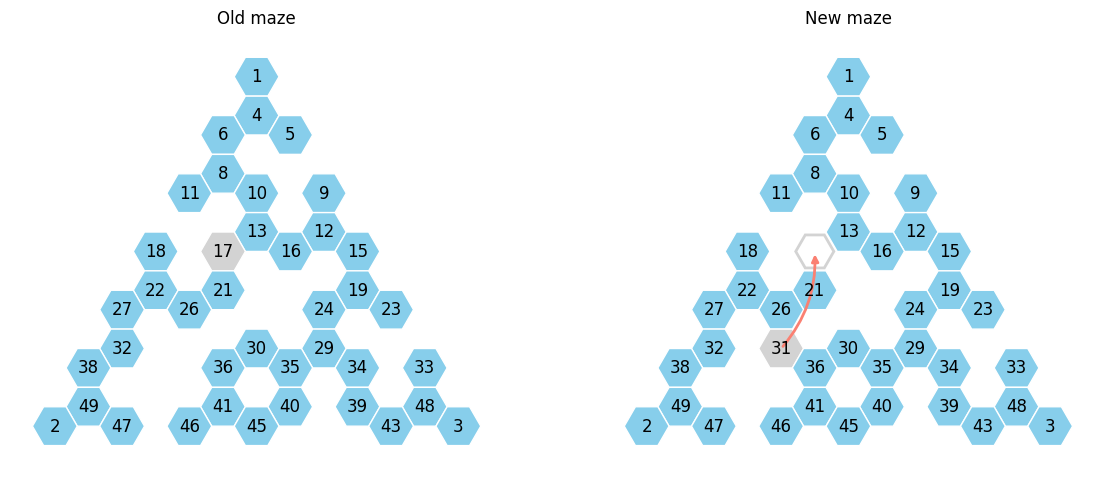

In [1]:
import sys
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("..")  # Use sys to add the parent directory (where src/hexmaze lives) to the path

from src.hexmaze import (
    plot_hex_maze,
    get_pairwise_distance_matrix,
    get_pairwise_distance_change,
    get_barrier_change,
    get_distance_change_blocks,
)

# A single-hue colormap for low-to-high values. The dark end stops short of full
# saturation so the black hex labels stay readable on the darkest hexes.
SEQUENTIAL_COLORMAP = matplotlib.colors.LinearSegmentedColormap.from_list(
    "purples_truncated", plt.get_cmap("Purples")([0.05 + 0.73 * i / 255 for i in range(256)])
)

# Load the barrier sequence database and grab 2 mazes that differ by one barrier
barrier_sequence_database = pd.read_pickle("../Barrier_Sequence_Databases/barrier_sequence_database.pkl")
sequence = barrier_sequence_database.iloc[3]["barrier_sequence"]
old_maze, new_maze = sequence[0], sequence[1]

old_barrier, new_barrier = get_barrier_change(old_maze, new_maze)
print(f"The barrier on hex {old_barrier} moved to hex {new_barrier}")

# The hexes involved in the barrier change have no distance to compare across mazes.
# They are excluded from the analysis, and shown in grey on every maze plot below.
excluded_hexes = {old_barrier, new_barrier}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_hex_maze(
    old_maze,
    ax=axes[0],
    show_barriers=False,
    show_barrier_change=False,
    highlight_hexes=excluded_hexes,
    highlight_colors="lightgrey",
    outline_hexes={new_barrier},
    outline_colors="lightgrey",
)
axes[0].set_title("Old maze")
plot_hex_maze(
    new_maze,
    ax=axes[1],
    old_barrier=old_barrier,
    new_barrier=new_barrier,
    show_barriers=False,
    show_barrier_change=False,
    highlight_hexes=excluded_hexes,
    highlight_colors="lightgrey",
    outline_hexes={new_barrier},
    outline_colors="lightgrey",
)
axes[1].set_title("New maze")
plt.show()

## 2. Compute pairwise distances on each maze

`get_hex_distance` gives the distance between a single pair of hexes. `get_pairwise_distance_matrix` gives the distance between every pair of open hexes in a maze, and `get_pairwise_distance_change` gives how much each of those distances changed from one maze to another.

`get_pairwise_distance_change` only compares hexes that are open in both mazes (the old barrier and new barrier hexes have no distance to compare, so they are excluded)


39 hexes open in both mazes (excluding hexes 31 (old barrier) and 17 (new barrier))


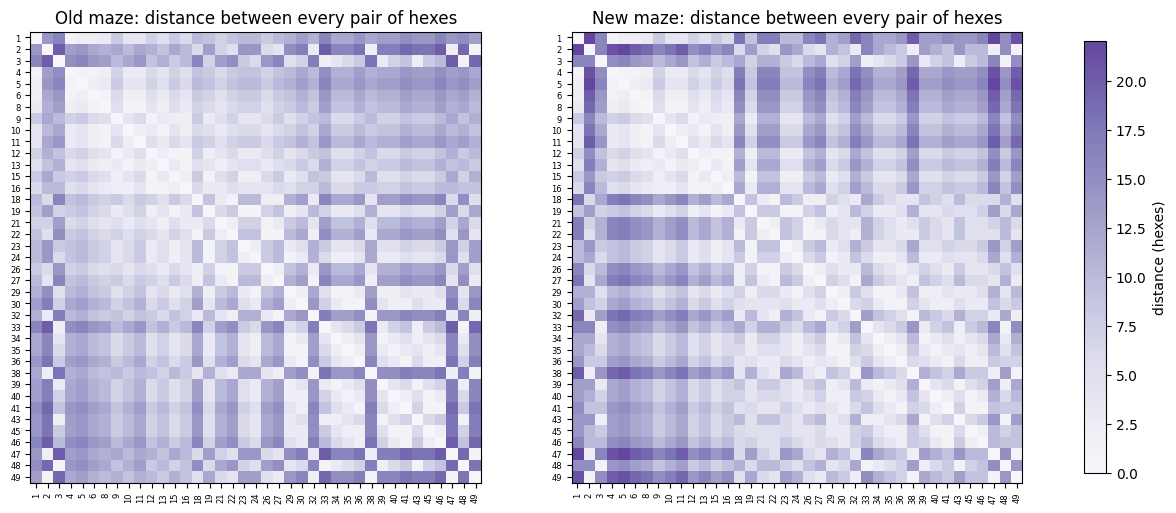

In [2]:
old_distances = get_pairwise_distance_matrix(old_maze)
new_distances = get_pairwise_distance_matrix(new_maze)

# Only hexes open in both mazes have a distance we can compare across mazes
shared_hexes = sorted(set(old_distances.index) & set(new_distances.index))
print(f"{len(shared_hexes)} hexes open in both mazes (excluding hexes {old_barrier} (old barrier) and {new_barrier} (new barrier))")

# Restrict each maze's distances to the shared hexes so the 2 matrices line up
old_distances = old_distances.loc[shared_hexes, shared_hexes]
new_distances = new_distances.loc[shared_hexes, shared_hexes]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Put both matrices on the same color scale so they are directly comparable
max_distance = max(old_distances.values.max(), new_distances.values.max())

for ax, distances, title in [
    (axes[0], old_distances, "Old maze"),
    (axes[1], new_distances, "New maze"),
]:
    image = ax.imshow(distances, cmap=SEQUENTIAL_COLORMAP, vmin=0, vmax=max_distance)
    ax.set_xticks(range(len(shared_hexes)), shared_hexes, fontsize=6, rotation=90)
    ax.set_yticks(range(len(shared_hexes)), shared_hexes, fontsize=6)
    ax.set_title(f"{title}: distance between every pair of hexes")

colorbar = fig.colorbar(image, ax=axes, shrink=0.8)
colorbar.set_label("distance (hexes)")
plt.show()

## 3. Compute pairwise distance changes as a result of the barrier shift

`get_pairwise_distance_change` has 3 sort options, all shown below:
- "hex" (default): no block ordering, just hexes in sorted order
- "similarity": blocks that changed in similar ways are next to each other
- "size": blocks in order of size, largest first

271 of 741 hex pairs (37%) changed distance
The largest change for a single pair is 10 hexes


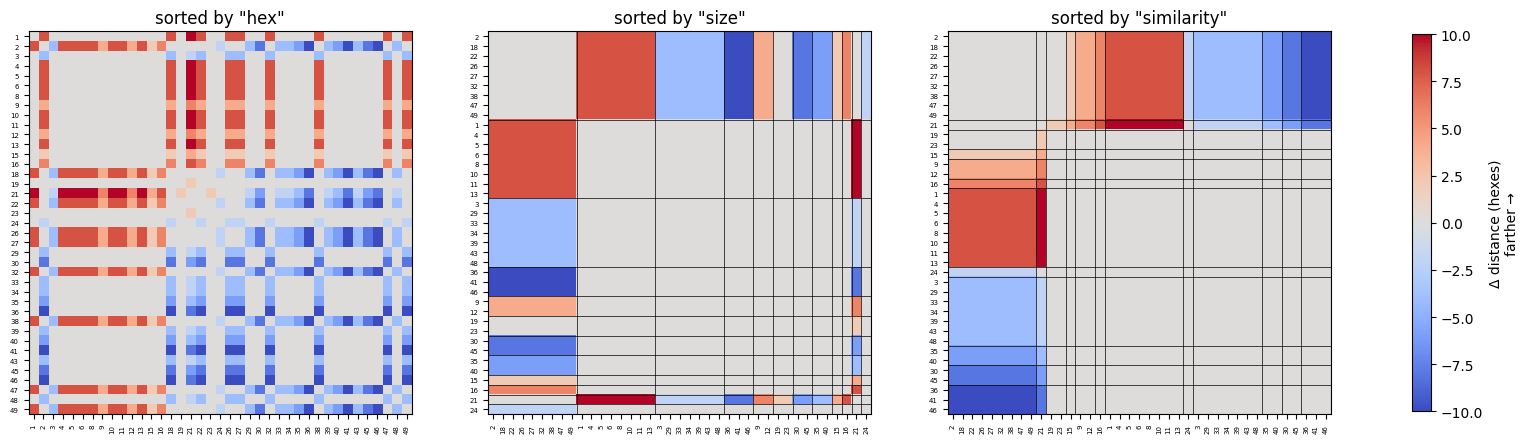

In [3]:
# Get matrix of pairwise hex distance changes
distance_change = get_pairwise_distance_change(old_maze, new_maze, sort_by="hex")

# Print some info about the distance changes
num_pairs = len(shared_hexes) * (len(shared_hexes) - 1) // 2
num_changed_pairs = int((distance_change.values != 0).sum() // 2)
print(f"{num_changed_pairs} of {num_pairs} hex pairs ({num_changed_pairs / num_pairs:.0%}) changed distance")
print(f"The largest change for a single pair is {int(distance_change.abs().values.max())} hexes")

# Center the diverging colormap on zero
largest_pair_change = distance_change.abs().values.max()

# Plot distance change matrix sorted by hex, size, and similarity
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, sort_by in zip(axes, ["hex", "size", "similarity"]):
    sorted_distance_change = get_pairwise_distance_change(old_maze, new_maze, sort_by=sort_by)

    image = ax.imshow(
        sorted_distance_change, cmap="coolwarm", vmin=-largest_pair_change, vmax=largest_pair_change
    )
    ax.set_xticks(
        range(len(sorted_distance_change)), sorted_distance_change.index, fontsize=5, rotation=90
    )
    ax.set_yticks(range(len(sorted_distance_change)), sorted_distance_change.index, fontsize=5)
    ax.set_title(f'sorted by "{sort_by}"')

    # Mark where one block ends and the next begins
    if sort_by != "hex":
        sorted_blocks = get_distance_change_blocks(old_maze, new_maze, sort_by=sort_by)
        block_edges = pd.Series([len(block) for block in sorted_blocks]).cumsum()[:-1]
        for edge in block_edges:
            ax.axhline(edge - 0.5, color="black", linewidth=0.5)
            ax.axvline(edge - 0.5, color="black", linewidth=0.5)

colorbar = fig.colorbar(image, ax=axes, shrink=0.7)
colorbar.set_label("Δ distance (hexes)\nfarther →")
plt.show()

## 4. Summarize the change per hex

Each hex has a change in distance to every other shared hex. Four potential ways to collapse those into a single number per hex:

- **number of changed partners**: how many other hexes this hex changed distance to at all
- **mean absolute change**: how much this hex's distances were rearranged, regardless of direction
- **mean signed change**: whether this hex got closer to (negative) or farther from (positive) the rest of the maze
- **max absolute change**: this hex's single most-changed partner

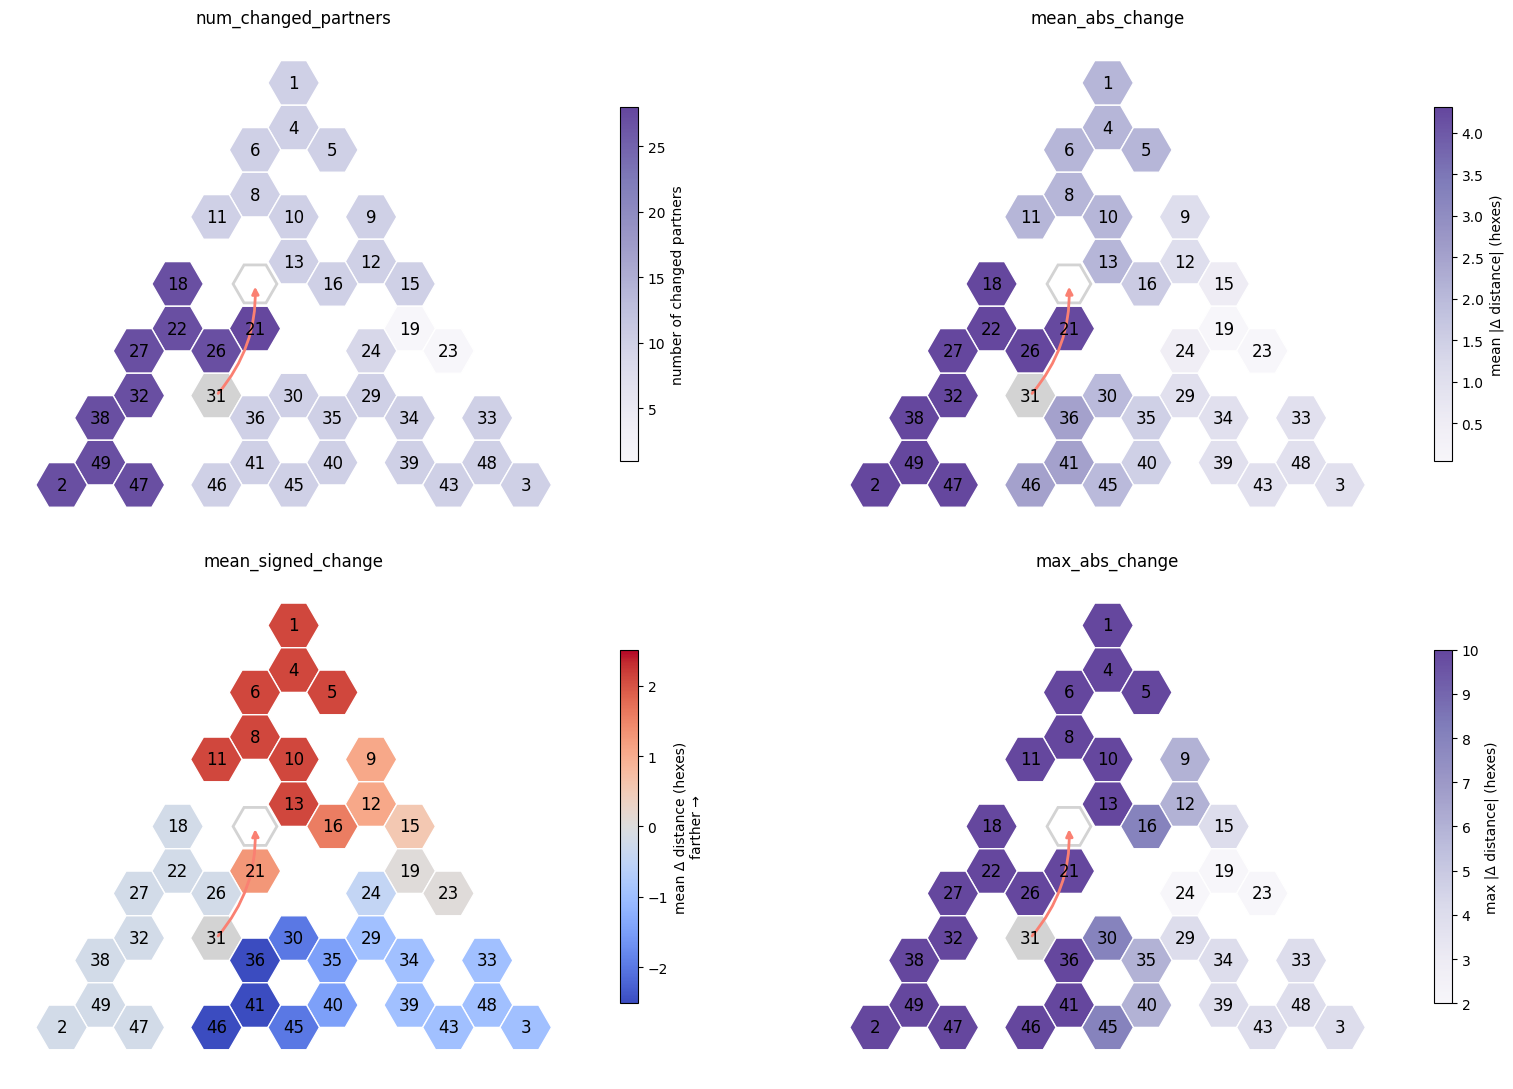

In [4]:
# Calculate some per-hex distance change metrics
hex_distance_change = pd.DataFrame(
    {
        "num_changed_partners": (distance_change != 0).sum(axis=1),
        "mean_abs_change": distance_change.abs().mean(axis=1),
        "mean_signed_change": distance_change.mean(axis=1),
        "max_abs_change": distance_change.abs().max(axis=1),
    }
)
hex_distance_change.index.name = "hex"

# Each metric, its colorbar label, colormap, and whether to center the colormap on zero
metrics_to_plot = [
    ("num_changed_partners", "number of changed partners", SEQUENTIAL_COLORMAP, False),
    ("mean_abs_change", "mean |Δ distance| (hexes)", SEQUENTIAL_COLORMAP, False),
    ("mean_signed_change", "mean Δ distance (hexes)\nfarther →", "coolwarm", True),
    ("max_abs_change", "max |Δ distance| (hexes)", SEQUENTIAL_COLORMAP, False),
]

# Plot the per-hex metrics on the maze
fig, axes = plt.subplots(2, 2, figsize=(17, 11))

for ax, (metric, label, colormap, center_on_zero) in zip(axes.flat, metrics_to_plot):
    values = hex_distance_change[metric].to_dict()

    # Diverging metrics are centered on zero so the color shows direction
    if center_on_zero:
        vmax = max(abs(value) for value in values.values())
        vmin = -vmax
    else:
        vmin, vmax = min(values.values()), max(values.values())

    plot_hex_maze(
        new_maze,
        ax=ax,
        old_barrier=old_barrier,
        new_barrier=new_barrier,
        show_barriers=False,
        show_barrier_change=False,
        highlight_hexes=excluded_hexes,
        highlight_colors="lightgrey",  # No data: not open in both mazes
        outline_hexes={new_barrier},
        outline_colors="lightgrey",  # Where the new barrier is
        color_by=values,
        colormap=colormap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(metric)

    colorbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap=colormap),
        ax=ax,
        shrink=0.7,
    )
    colorbar.set_label(label)

plt.tight_layout()
plt.show()

## 5. Change in distance to each reward port

The reference hexes we usually care about are the reward ports, since those are (theoretically) the locations the rat cares about the distance to. Taking the port's column of `distance_change` gives every hex's change in distance to that port. All 3 ports share a color scale so they are directly comparable: blue hexes got closer to that port, red hexes got farther from it.

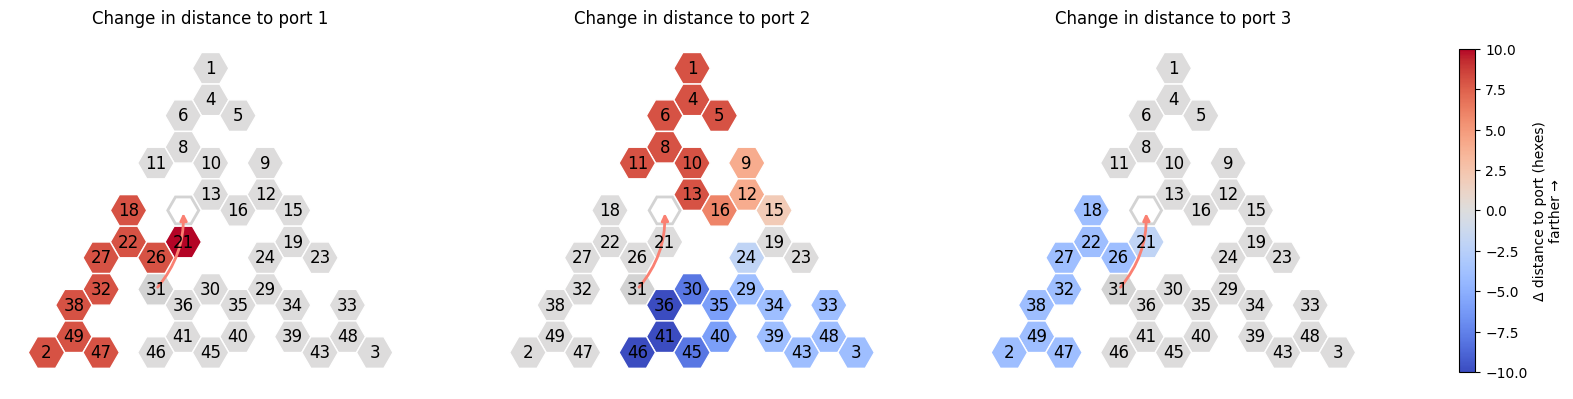

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Put all 3 ports on the same color scale so they are directly comparable
largest_change_to_ports = max(distance_change[port].abs().max() for port in (1, 2, 3))

for ax, port in zip(axes, (1, 2, 3)):
    plot_hex_maze(
        new_maze,
        ax=ax,
        old_barrier=old_barrier,
        new_barrier=new_barrier,
        show_barriers=False,
        show_barrier_change=False,
        highlight_hexes=excluded_hexes,
        highlight_colors="lightgrey",  # No data: not open in both mazes
        outline_hexes={new_barrier},
        outline_colors="lightgrey",  # Where the new barrier is
        color_by=distance_change[port].to_dict(),
        colormap="coolwarm",
        vmin=-largest_change_to_ports,
        vmax=largest_change_to_ports,
    )
    ax.set_title(f"Change in distance to port {port}")

colorbar = fig.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(vmin=-largest_change_to_ports, vmax=largest_change_to_ports),
        cmap="coolwarm",
    ),
    ax=axes,
    shrink=0.6,
)
colorbar.set_label("Δ distance to port (hexes)\nfarther →")
plt.show()

Combining a hex's change in distance to all 3 ports gives a measure of how much the barrier change moved that hex relative to the reward ports. 

- **mean absolute change to ports**: how much this hex's distance to the reward ports changed
- **mean signed change to ports**: whether this hex is now farther from reward overall (positive) or closer to it (negative)

A hex that moved 5 hexes closer to one port and 5 hexes farther from another scores high on the first and zero on the second.

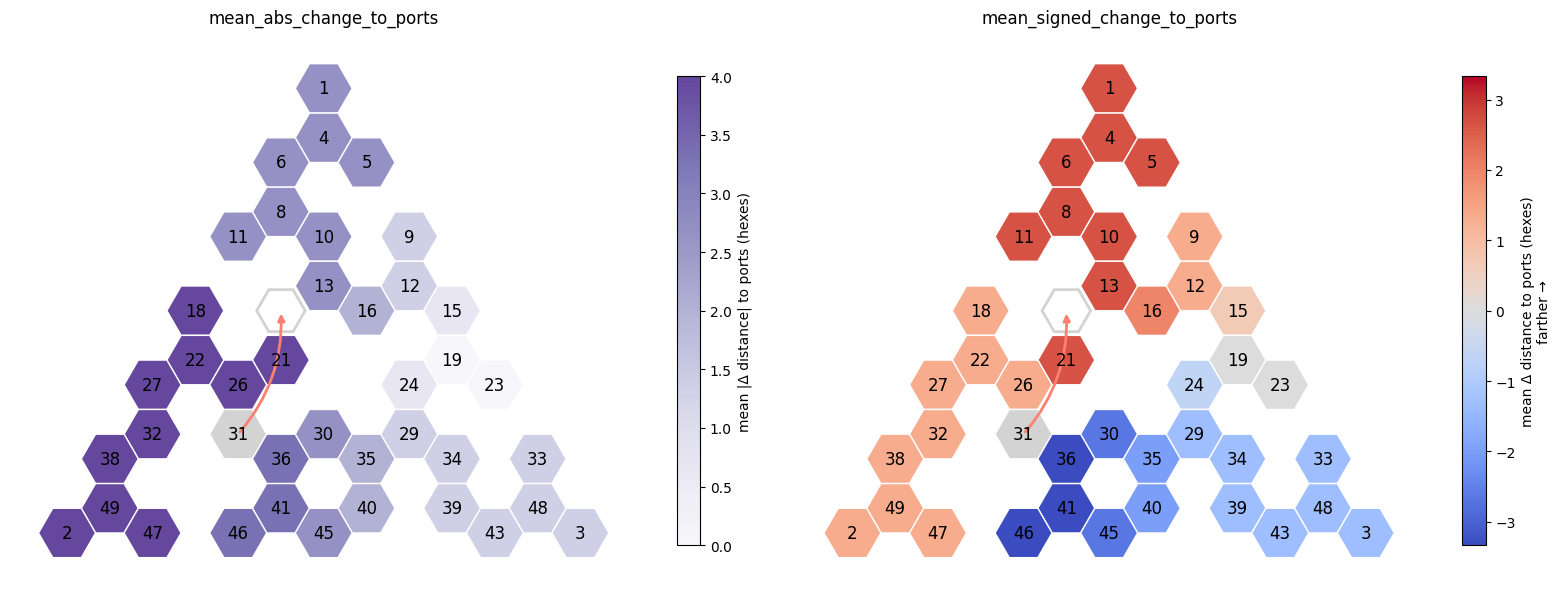

,num_changed_partners,mean_abs_change,mean_signed_change,max_abs_change,mean_abs_change_to_ports,mean_signed_change_to_ports
hex,,,,,,
49,27,4.307692,-0.205128,10,4.0,1.333333
21,28,4.256410,1.282051,10,4.0,2.666667
47,27,4.307692,-0.205128,10,4.0,1.333333
38,27,4.307692,-0.205128,10,4.0,1.333333
32,27,4.307692,-0.205128,10,4.0,1.333333
27,27,4.307692,-0.205128,10,4.0,1.333333
26,27,4.307692,-0.205128,10,4.0,1.333333
2,27,4.307692,-0.205128,10,4.0,1.333333
22,27,4.307692,-0.205128,10,4.0,1.333333


In [6]:
# Combine each hex's change in distance to the 3 reward ports
port_changes = distance_change[[1, 2, 3]]
hex_distance_change["mean_abs_change_to_ports"] = port_changes.abs().mean(axis=1)
hex_distance_change["mean_signed_change_to_ports"] = port_changes.mean(axis=1)

combined_metrics_to_plot = [
    ("mean_abs_change_to_ports", "mean |Δ distance| to ports (hexes)", SEQUENTIAL_COLORMAP, False),
    ("mean_signed_change_to_ports", "mean Δ distance to ports (hexes)\nfarther →", "coolwarm", True),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (metric, label, colormap, center_on_zero) in zip(axes, combined_metrics_to_plot):
    values = hex_distance_change[metric].to_dict()

    # Diverging metrics are centered on zero so the color shows direction
    if center_on_zero:
        vmax = max(abs(value) for value in values.values())
        vmin = -vmax
    else:
        vmin, vmax = min(values.values()), max(values.values())

    plot_hex_maze(
        new_maze,
        ax=ax,
        old_barrier=old_barrier,
        new_barrier=new_barrier,
        show_barriers=False,
        show_barrier_change=False,
        highlight_hexes=excluded_hexes,
        highlight_colors="lightgrey",  # No data: not open in both mazes
        outline_hexes={new_barrier},
        outline_colors="lightgrey",  # Where the new barrier is
        color_by=values,
        colormap=colormap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(metric)

    colorbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap=colormap),
        ax=ax,
        shrink=0.7,
    )
    colorbar.set_label(label)

plt.tight_layout()
plt.show()

hex_distance_change.sort_values("mean_abs_change_to_ports", ascending=False).head(10)

## 6. Blocks of hexes that move together

Grouping hexes by their entire row of `distance_change` collapses the matrix into a handful of blocks, where every hex in a block changed distance by the same amount to every hex outside it, and distances *within* a block did not change at all. The barrier change slides these blocks relative to each other rather than rearranging the maze hex by hex.

Blocks containing a single hex are hexes that moved on their own, which tend to lie on the re-routed corridor itself.

39 hexes fall into 12 blocks that moved together:
   9 hexes: [2, 18, 22, 26, 27, 32, 38, 47, 49]
   2 hexes: [19, 23]
   2 hexes: [9, 12]
   8 hexes: [1, 4, 5, 6, 8, 10, 11, 13]
   7 hexes: [3, 29, 33, 34, 39, 43, 48]
   2 hexes: [35, 40]
   2 hexes: [30, 45]
   3 hexes: [36, 41, 46]
  4 single hexes: [15, 16, 21, 24]


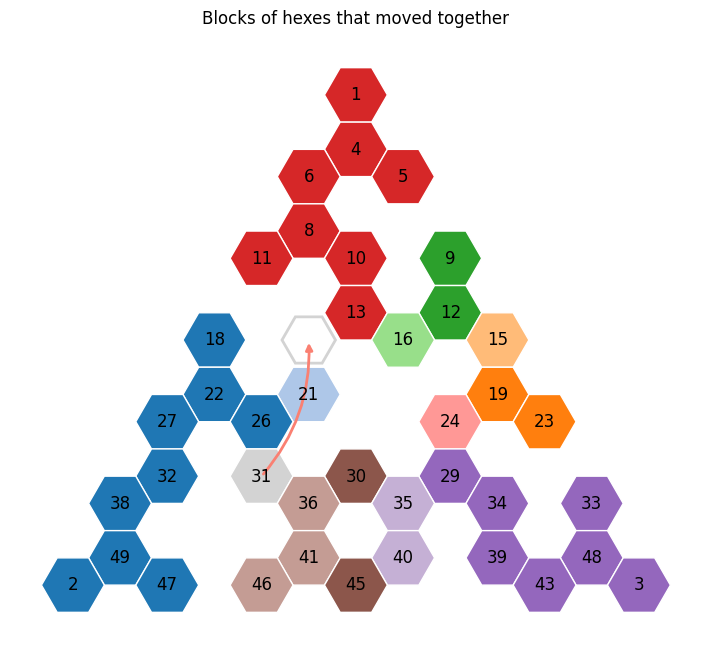

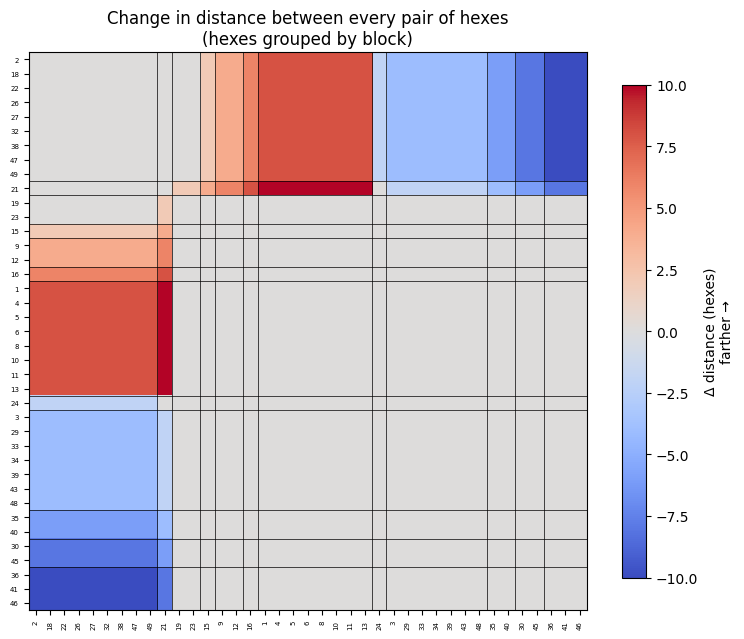

In [7]:
blocks = get_distance_change_blocks(old_maze, new_maze, sort_by="similarity")

print(f"{len(shared_hexes)} hexes fall into {len(blocks)} blocks that moved together:")
for block in blocks:
    if len(block) > 1:
        print(f"  {len(block):2d} hexes: {block}")
print(f"  {sum(len(block) == 1 for block in blocks)} single hexes: "
      f"{sorted(block[0] for block in blocks if len(block) == 1)}")

# Give each block its own color, and keep the no-data hexes grey
block_colors = [matplotlib.colormaps["tab20"](i % 20) for i in range(len(blocks))]

fig, ax = plt.subplots(figsize=(9, 8))
plot_hex_maze(
    new_maze,
    ax=ax,
    old_barrier=old_barrier,
    new_barrier=new_barrier,
    show_barriers=False,
    show_barrier_change=False,
    highlight_hexes=[set(block) for block in blocks] + [excluded_hexes],
    highlight_colors=block_colors + ["lightgrey"],  # No data: not open in both mazes
    outline_hexes={new_barrier},
    outline_colors="lightgrey",  # Where the new barrier is
)
ax.set_title("Blocks of hexes that moved together")
plt.show()


# Show the change matrix with hexes in the same block order as the maze above
sorted_distance_change = get_pairwise_distance_change(old_maze, new_maze, sort_by="similarity")

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(
    sorted_distance_change, cmap="coolwarm", vmin=-largest_pair_change, vmax=largest_pair_change
)
ax.set_xticks(
    range(len(sorted_distance_change)), sorted_distance_change.index, fontsize=5, rotation=90
)
ax.set_yticks(range(len(sorted_distance_change)), sorted_distance_change.index, fontsize=5)
ax.set_title("Change in distance between every pair of hexes\n(hexes grouped by block)")

# Mark where one block ends and the next begins
block_edges = pd.Series([len(block) for block in blocks]).cumsum()[:-1]
for edge in block_edges:
    ax.axhline(edge - 0.5, color="black", linewidth=0.5)
    ax.axvline(edge - 0.5, color="black", linewidth=0.5)

colorbar = fig.colorbar(image, ax=ax, shrink=0.8)
colorbar.set_label("Δ distance (hexes)\nfarther →")
plt.show()
